<a href="https://colab.research.google.com/github/www-fidezDAE/fidez.RDS/blob/main/Naive_Bayes_and_SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Simulation and Modelling Course

Naive Bayes Train Accuracy:  0.7619047619047619
Naive Bayes Test Accuracy:  0.1111111111111111
SVM Train Accuracy:  0.3333333333333333
SVM Test Accuracy:  0.1111111111111111
Naive Bayes Classification Report (Test):
              precision    recall  f1-score   support

          78       0.00      0.00      0.00         0
          79       0.00      0.00      0.00         1
          80       0.00      0.00      0.00         1
          82       0.00      0.00      0.00         1
          83       0.50      0.33      0.40         3
          84       0.00      0.00      0.00         0
          87       0.00      0.00      0.00         1
          91       0.00      0.00      0.00         1
          92       0.00      0.00      0.00         1

    accuracy                           0.11         9
   macro avg       0.06      0.04      0.04         9
weighted avg       0.17      0.11      0.13         9

SVM Classification Report (Test):
              precision    recall  f1-score  

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.

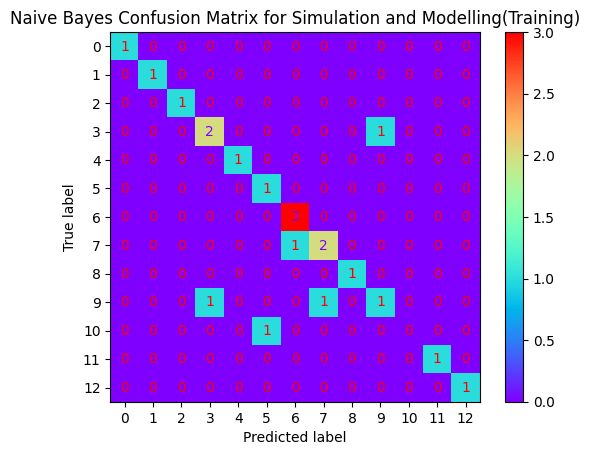

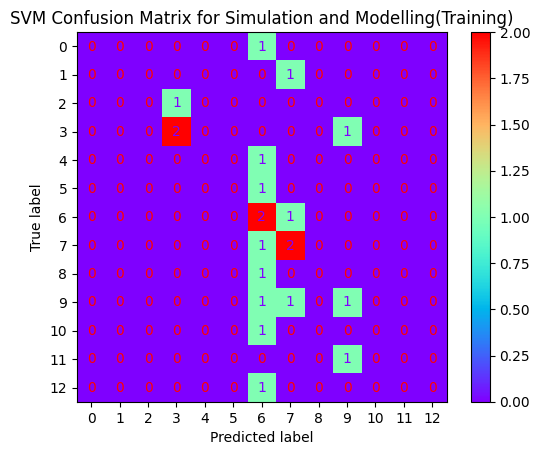

Fitting 3 folds for each of 12 candidates, totalling 36 fits


/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_split.py:737: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(


Best parameters found:  {'C': 0.1, 'kernel': 'rbf'}
Naive Bayes Accuracy on Large Dataset: 0.6555555555555556
Naive Bayes Time Taken on Large Dataset: 0.006594181060791016 seconds

SVM Accuracy on Large Dataset: 0.34
SVM Time Taken on Large Dataset: 0.17847251892089844 seconds



In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import precision_recall_fscore_support, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import time
import seaborn as sns

# Step 1: Load the data
data = {
    'Interest': [8.2, 4.6, 10, 10, 7.8, 8.8, 8, 7.8, 7.2, 10, 6.2, 4.8, 6.8, 7, 7.742857143, 7.085714286, 7.7,
                 7.228571429, 7.3, 6.857142857, 7.871428571, 7.342857143, 7.4, 8.171428571, 6.9, 7.485714286,
                 7.957142857, 7.942857143, 7.457142857, 7.214285714],
    'Performance': [88, 88, 78, 78, 82, 77, 94, 90, 91, 92, 93, 78, 80, 88, 81, 79, 68, 83, 73, 84, 83, 83,
                    85, 87, 83, 83, 84, 83, 82, 84]
}

df = pd.DataFrame(data)

# Define features and target
X = df[['Interest']]  # Independent variable (Interest)
y = df['Performance']  # Dependent variable (Performance)

# Step 2: Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Step 3: Train Naive Bayes and SVM Models
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

svm_model = SVC(kernel='linear')
svm_model.fit(X_train, y_train)

# Step 4: Evaluate Naive Bayes
nb_predictions_train = nb_model.predict(X_train)
nb_predictions_test = nb_model.predict(X_test)

nb_train_accuracy = accuracy_score(y_train, nb_predictions_train)
nb_test_accuracy = accuracy_score(y_test, nb_predictions_test)

print("Naive Bayes Train Accuracy: ", nb_train_accuracy)
print("Naive Bayes Test Accuracy: ", nb_test_accuracy)

# Step 5: Evaluate SVM
svm_predictions_train = svm_model.predict(X_train)
svm_predictions_test = svm_model.predict(X_test)

svm_train_accuracy = accuracy_score(y_train, svm_predictions_train)
svm_test_accuracy = accuracy_score(y_test, svm_predictions_test)

print("SVM Train Accuracy: ", svm_train_accuracy)
print("SVM Test Accuracy: ", svm_test_accuracy)

# Classification report and performance metrics
print("Naive Bayes Classification Report (Test):")
print(classification_report(y_test, nb_predictions_test))

print("SVM Classification Report (Test):")
print(classification_report(y_test, svm_predictions_test))

# Confusion Matrix Plot (Naive Bayes)
nb_conf_matrix = confusion_matrix(y_train, nb_predictions_train)
disp_nb = ConfusionMatrixDisplay(confusion_matrix=nb_conf_matrix)
disp_nb.plot(cmap='rainbow')
plt.title('Naive Bayes Confusion Matrix for Simulation and Modelling(Training)')
plt.show()

# Confusion Matrix Plot (SVM)
svm_conf_matrix = confusion_matrix(y_train, svm_predictions_train)
disp_svm = ConfusionMatrixDisplay(confusion_matrix=svm_conf_matrix)
disp_svm.plot(cmap='rainbow')
plt.title('SVM Confusion Matrix for Simulation and Modelling(Training)')
plt.show()

# Step 6: Hyperparameter tuning using Grid Search
param_grid = {'C': [0.1, 1, 10, 100], 'kernel': ['linear', 'rbf', 'poly']}
grid_search = GridSearchCV(SVC(), param_grid, refit=True, verbose=1, cv=3)  # Reduce to 3 folds
grid_search.fit(X_train, y_train)

# Best parameters found through Grid Search
print("Best parameters found: ", grid_search.best_params_)

# Step 7: Simulate Larger Datasets and Perform Scalability Test
large_X = pd.DataFrame(np.tile(X.values, (100, 1)), columns=['Interest'])
large_y = np.tile(y.values, 100)

# Split the large dataset
X_train_large, X_test_large, y_train_large, y_test_large = train_test_split(large_X, large_y, test_size=0.3, random_state=42)

# Measure the time taken by Naive Bayes on large dataset
start_time = time.time()
nb_model.fit(X_train_large, y_train_large)
nb_large_predictions = nb_model.predict(X_test_large)
nb_large_accuracy = accuracy_score(y_test_large, nb_large_predictions)
nb_time_taken = time.time() - start_time

# Measure the time taken by SVM on large dataset
start_time = time.time()
svm_model.fit(X_train_large, y_train_large)
svm_large_predictions = svm_model.predict(X_test_large)
svm_large_accuracy = accuracy_score(y_test_large, svm_large_predictions)
svm_time_taken = time.time() - start_time

print(f"Naive Bayes Accuracy on Large Dataset: {nb_large_accuracy}")
print(f"Naive Bayes Time Taken on Large Dataset: {nb_time_taken} seconds\n")

print(f"SVM Accuracy on Large Dataset: {svm_large_accuracy}")
print(f"SVM Time Taken on Large Dataset: {svm_time_taken} seconds\n")

Naive Bayes Sensitivity: 0
Naive Bayes Specificity: 0
SVM Sensitivity: 0
SVM Specificity: 0
Naive Bayes Cross-Validation Scores: [0.3 0.1 0.2]
Naive Bayes Mean CV Score: 0.20000000000000004
SVM Cross-Validation Scores: [0.2 0.2 0.2]
SVM Mean CV Score: 0.20000000000000004


/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_split.py:737: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_split.py:737: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(


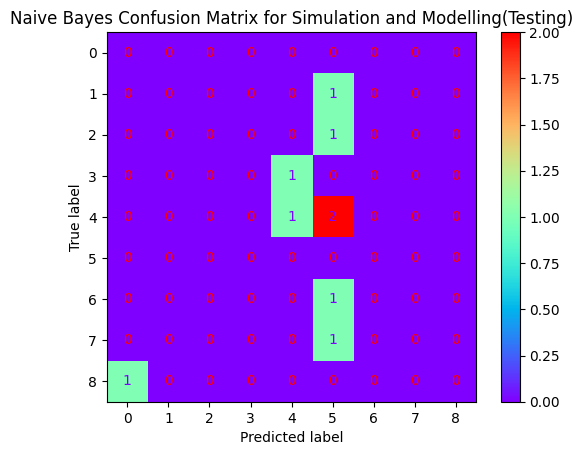

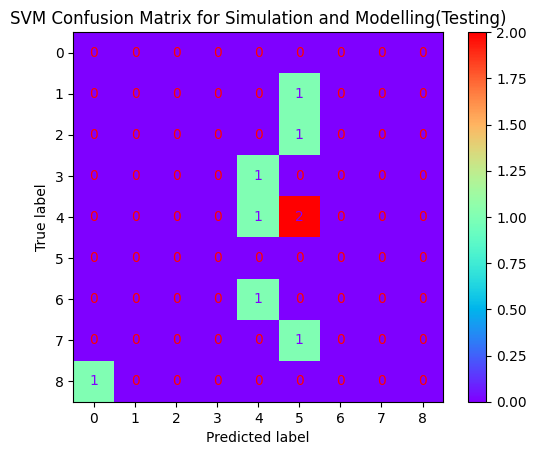

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import precision_recall_fscore_support, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Load the data
data = {
    'Interest': [8.2, 4.6, 10, 10, 7.8, 8.8, 8, 7.8, 7.2, 10, 6.2, 4.8, 6.8, 7, 7.742857143, 7.085714286, 7.7,
                 7.228571429, 7.3, 6.857142857, 7.871428571, 7.342857143, 7.4, 8.171428571, 6.9, 7.485714286,
                 7.957142857, 7.942857143, 7.457142857, 7.214285714],
    'Performance_in_Simulation_and_Modelling': [88, 88, 78, 78, 82, 77, 94, 90, 91, 92, 93, 78, 80, 88, 81, 79, 68, 83, 73, 84, 83, 83,
                    85, 87, 83, 83, 84, 83, 82, 84]
}

df = pd.DataFrame(data)

# Define features and target
X = df[['Interest']]  # Independent variable (Interest)
y = df['Performance_in_Simulation_and_Modelling']  # Dependent variable (Performance)

# Step 2: Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Step 3: Train Naive Bayes and SVM Models
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

svm_model = SVC(kernel='linear')
svm_model.fit(X_train, y_train)

# Step 4: Evaluate Naive Bayes
nb_predictions_test = nb_model.predict(X_test)

# Evaluate SVM
svm_predictions_test = svm_model.predict(X_test)

# Step 5: Confusion Matrix for both models
nb_conf_matrix = confusion_matrix(y_test, nb_predictions_test)
svm_conf_matrix = confusion_matrix(y_test, svm_predictions_test)

# Step 6: Sensitivity (Recall) and Specificity Calculation from the Confusion Matrix
def calculate_sensitivity_specificity(conf_matrix):
    # True positives, False negatives, False positives, True negatives
    TP = conf_matrix[1, 1]
    FN = conf_matrix[1, 0]
    FP = conf_matrix[0, 1]
    TN = conf_matrix[0, 0]

    # Sensitivity (Recall) = TP / (TP + FN)
    sensitivity = TP / (TP + FN) if (TP + FN) != 0 else 0
    # Specificity = TN / (TN + FP)
    specificity = TN / (TN + FP) if (TN + FP) != 0 else 0

    return sensitivity, specificity

# Naive Bayes Sensitivity and Specificity
nb_sensitivity, nb_specificity = calculate_sensitivity_specificity(nb_conf_matrix)
print(f"Naive Bayes Sensitivity: {nb_sensitivity}")
print(f"Naive Bayes Specificity: {nb_specificity}")

# SVM Sensitivity and Specificity
svm_sensitivity, svm_specificity = calculate_sensitivity_specificity(svm_conf_matrix)
print(f"SVM Sensitivity: {svm_sensitivity}")
print(f"SVM Specificity: {svm_specificity}")

# Step 7: Cross-Validation
nb_cv_scores = cross_val_score(nb_model, X, y, cv=3)  # 3-fold cross-validation
print(f"Naive Bayes Cross-Validation Scores: {nb_cv_scores}")
print(f"Naive Bayes Mean CV Score: {np.mean(nb_cv_scores)}")

svm_cv_scores = cross_val_score(svm_model, X, y, cv=3)  # 3-fold cross-validation
print(f"SVM Cross-Validation Scores: {svm_cv_scores}")
print(f"SVM Mean CV Score: {np.mean(svm_cv_scores)}")

# Confusion Matrix Plot (Naive Bayes)
disp_nb = ConfusionMatrixDisplay(confusion_matrix=nb_conf_matrix)
disp_nb.plot(cmap='rainbow')
plt.title('Naive Bayes Confusion Matrix for Simulation and Modelling(Testing)')
plt.show()

# Confusion Matrix Plot (SVM)
disp_svm = ConfusionMatrixDisplay(confusion_matrix=svm_conf_matrix)
disp_svm.plot(cmap='rainbow')
plt.title('SVM Confusion Matrix for Simulation and Modelling(Testing)')
plt.show()

Naive Bayes Sensitivity: 1.0
Naive Bayes Specificity: 1.0
SVM Sensitivity: 0
SVM Specificity: 0
Naive Bayes Cross-Validation Scores: [0.3 0.1 0.2]
Naive Bayes Mean CV Score: 0.20000000000000004
SVM Cross-Validation Scores: [0.2 0.2 0.2]
SVM Mean CV Score: 0.20000000000000004
The best model is: SVM
Predicted Values for 24 Leads:  [83 83 83 78 84 88 83 88 78 83 78 84 83 84 84 83 83 88 83 84 83]


/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_split.py:737: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_split.py:737: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(


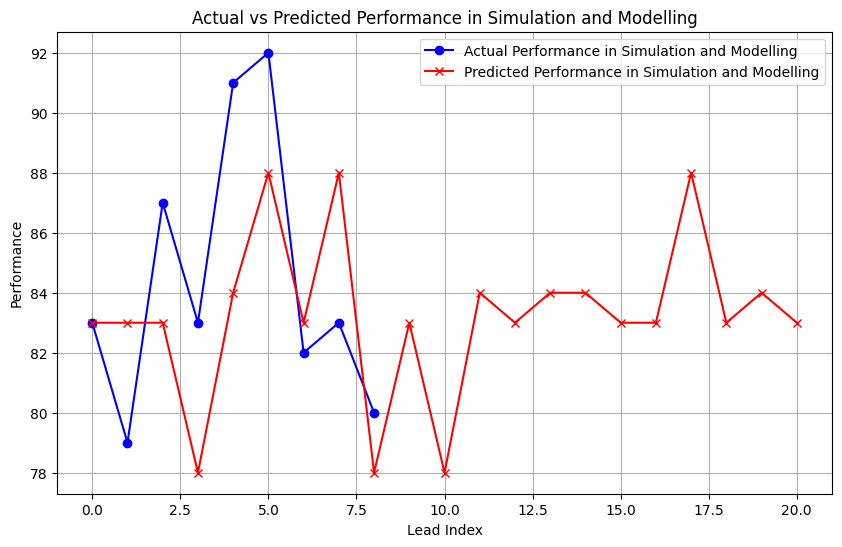

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import precision_recall_fscore_support, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Load the data
data = {
    'Interest': [8.2, 4.6, 10, 10, 7.8, 8.8, 8, 7.8, 7.2, 10, 6.2, 4.8, 6.8, 7, 7.742857143, 7.085714286, 7.7,
                 7.228571429, 7.3, 6.857142857, 7.871428571, 7.342857143, 7.4, 8.171428571, 6.9, 7.485714286,
                 7.957142857, 7.942857143, 7.457142857, 7.214285714],
    'Performance_in_Simulation_and_Modelling': [88, 88, 78, 78, 82, 77, 94, 90, 91, 92, 93, 78, 80, 88, 81, 79, 68, 83, 73, 84, 83, 83,
                    85, 87, 83, 83, 84, 83, 82, 84]
}

df = pd.DataFrame(data)

# Define features and target
X = df[['Interest']]  # Independent variable (Interest)
y = df['Performance_in_Simulation_and_Modelling']  # Dependent variable (Performance)

# Step 2: Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Step 3: Train Naive Bayes and SVM Models
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

svm_model = SVC(kernel='linear')
svm_model.fit(X_train, y_train)

# Step 4: Evaluate Naive Bayes
nb_predictions_test = nb_model.predict(X_train)

# Evaluate SVM
svm_predictions_test = svm_model.predict(X_train)

# Step 5: Confusion Matrix for both models
nb_conf_matrix = confusion_matrix(y_train, nb_predictions_train)
svm_conf_matrix = confusion_matrix(y_train, svm_predictions_train)

# Step 6: Sensitivity (Recall) and Specificity Calculation from the Confusion Matrix
def calculate_sensitivity_specificity(conf_matrix):
    # True positives, False negatives, False positives, True negatives
    TP = conf_matrix[1, 1]
    FN = conf_matrix[1, 0]
    FP = conf_matrix[0, 1]
    TN = conf_matrix[0, 0]

    # Sensitivity (Recall) = TP / (TP + FN)
    sensitivity = TP / (TP + FN) if (TP + FN) != 0 else 0
    # Specificity = TN / (TN + FP)
    specificity = TN / (TN + FP) if (TN + FP) != 0 else 0

    return sensitivity, specificity

# Naive Bayes Sensitivity and Specificity
nb_sensitivity, nb_specificity = calculate_sensitivity_specificity(nb_conf_matrix)
print(f"Naive Bayes Sensitivity: {nb_sensitivity}")
print(f"Naive Bayes Specificity: {nb_specificity}")

# SVM Sensitivity and Specificity
svm_sensitivity, svm_specificity = calculate_sensitivity_specificity(svm_conf_matrix)
print(f"SVM Sensitivity: {svm_sensitivity}")
print(f"SVM Specificity: {svm_specificity}")

# Step 7: Cross-Validation
nb_cv_scores = cross_val_score(nb_model, X, y, cv=3)  # 3-fold cross-validation
print(f"Naive Bayes Cross-Validation Scores: {nb_cv_scores}")
print(f"Naive Bayes Mean CV Score: {np.mean(nb_cv_scores)}")

svm_cv_scores = cross_val_score(svm_model, X, y, cv=3)  # 3-fold cross-validation
print(f"SVM Cross-Validation Scores: {svm_cv_scores}")
print(f"SVM Mean CV Score: {np.mean(svm_cv_scores)}")

# Compare the models and select the one with better performance (based on CV score)
best_model = nb_model if np.mean(nb_cv_scores) > np.mean(svm_cv_scores) else svm_model
print(f"The best model is: {'Naive Bayes' if best_model == nb_model else 'SVM'}")

# Step 8: Predict performance for 24 leads
predicted_values = best_model.predict(X_train[:24])
print("Predicted Values for 24 Leads: ", predicted_values)

# Step 9: Plot actual vs predicted values
plt.figure(figsize=(10,6))
plt.plot(y_test[:24].values, label="Actual Performance in Simulation and Modelling", color='blue', marker='o')
plt.plot(predicted_values, label="Predicted Performance in Simulation and Modelling", color='red', marker='x')
plt.title("Actual vs Predicted Performance in Simulation and Modelling")
plt.xlabel("Lead Index")
plt.ylabel("Performance")
plt.legend()
plt.grid(True)
plt.show()

Probability and Statistics Course

Naive Bayes Train Accuracy:  0.8095238095238095
Naive Bayes Test Accuracy:  0.0
SVM Train Accuracy:  0.2857142857142857
SVM Test Accuracy:  0.0
Naive Bayes Classification Report (Test):
              precision    recall  f1-score   support

          36       0.00      0.00      0.00       0.0
          54       0.00      0.00      0.00       1.0
          56       0.00      0.00      0.00       0.0
          60       0.00      0.00      0.00       1.0
          61       0.00      0.00      0.00       0.0
          64       0.00      0.00      0.00       1.0
          67       0.00      0.00      0.00       0.0
          71       0.00      0.00      0.00       1.0
          72       0.00      0.00      0.00       1.0
          77       0.00      0.00      0.00       1.0
          78       0.00      0.00      0.00       1.0
          86       0.00      0.00      0.00       1.0
          91       0.00      0.00      0.00       1.0

    accuracy                           0.00       9.0
  

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.

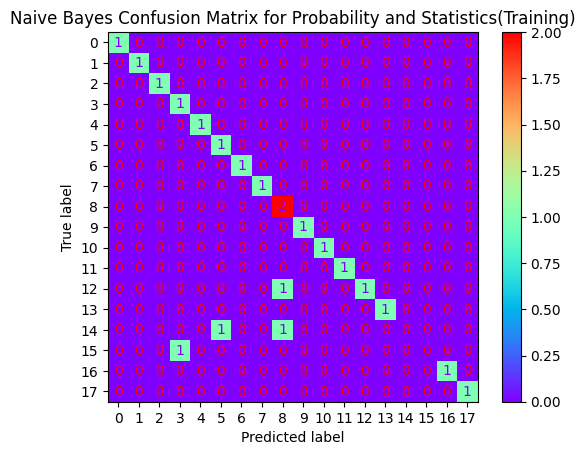

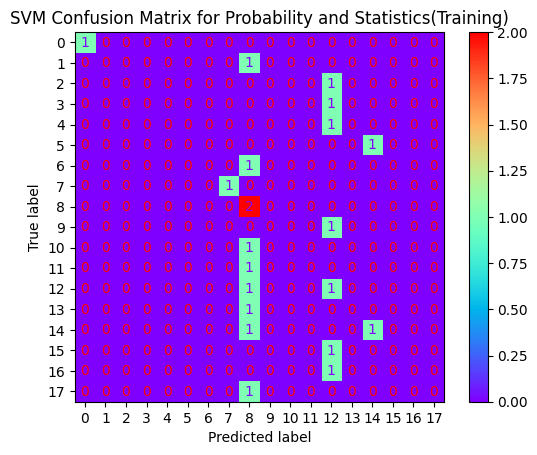

Fitting 2 folds for each of 12 candidates, totalling 24 fits


/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_split.py:737: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=2.
  warnings.warn(


Best parameters found:  {'C': 0.1, 'kernel': 'linear'}
Naive Bayes Accuracy on Large Dataset: 0.7622222222222222
Naive Bayes Time Taken on Large Dataset: 0.013605833053588867 seconds

SVM Accuracy on Large Dataset: 0.2011111111111111
SVM Time Taken on Large Dataset: 0.1883237361907959 seconds



In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import precision_recall_fscore_support, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import time
import seaborn as sns

# Step 1: Load the data
data = {
    'Interest': [8.4, 4.2, 10.0, 10.0, 6.8, 7.2, 8.2, 8.2, 6.4, 10.0, 6.4, 5.4, 6.2, 7.4, 7.6, 7.728571429, 7.385714286, 7.914285714, 7.528571429, 7.757142857, 7.142857143, 7.471428571, 8.0, 7.742857143, 7.114285714, 7.271428571, 7.9, 7.871428571, 7.2, 7.128571429],
    'Performance': [67, 59, 56, 71, 61, 36, 53, 73, 71, 64, 64, 26, 54, 61, 62, 60, 70, 77, 57, 55, 88, 67, 52, 72, 78, 63, 81, 86, 91, 71]
}

df = pd.DataFrame(data)

# Define features and target
X = df[['Interest']]  # Independent variable (Interest)
y = df['Performance']  # Dependent variable (Performance)

# Step 2: Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Step 3: Train Naive Bayes and SVM Models
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

svm_model = SVC(kernel='linear')
svm_model.fit(X_train, y_train)

# Step 4: Evaluate Naive Bayes
nb_predictions_train = nb_model.predict(X_train)
nb_predictions_test = nb_model.predict(X_test)

nb_train_accuracy = accuracy_score(y_train, nb_predictions_train)
nb_test_accuracy = accuracy_score(y_test, nb_predictions_test)

print("Naive Bayes Train Accuracy: ", nb_train_accuracy)
print("Naive Bayes Test Accuracy: ", nb_test_accuracy)

# Step 5: Evaluate SVM
svm_predictions_train = svm_model.predict(X_train)
svm_predictions_test = svm_model.predict(X_test)

svm_train_accuracy = accuracy_score(y_train, svm_predictions_train)
svm_test_accuracy = accuracy_score(y_test, svm_predictions_test)

print("SVM Train Accuracy: ", svm_train_accuracy)
print("SVM Test Accuracy: ", svm_test_accuracy)

# Classification report and performance metrics
print("Naive Bayes Classification Report (Test):")
print(classification_report(y_test, nb_predictions_test))

print("SVM Classification Report (Test):")
print(classification_report(y_test, svm_predictions_test))

# Confusion Matrix Plot (Naive Bayes)
nb_conf_matrix = confusion_matrix(y_train, nb_predictions_train)
disp_nb = ConfusionMatrixDisplay(confusion_matrix=nb_conf_matrix)
disp_nb.plot(cmap='rainbow')
plt.title('Naive Bayes Confusion Matrix for Probability and Statistics(Training)')
plt.show()

# Confusion Matrix Plot (SVM)
svm_conf_matrix = confusion_matrix(y_train, svm_predictions_train)
disp_svm = ConfusionMatrixDisplay(confusion_matrix=svm_conf_matrix)
disp_svm.plot(cmap='rainbow')
plt.title('SVM Confusion Matrix for Probability and Statistics(Training)')
plt.show()

# Step 6: Hyperparameter tuning using Grid Search
param_grid = {'C': [0.1, 1, 10, 100], 'kernel': ['linear', 'rbf', 'poly']}
grid_search = GridSearchCV(SVC(), param_grid, refit=True, verbose=1, cv=2)  # Reduce to 2 folds
grid_search.fit(X_train, y_train)

# Best parameters found through Grid Search
print("Best parameters found: ", grid_search.best_params_)

# Step 7: Simulate Larger Datasets and Perform Scalability Test
large_X = pd.DataFrame(np.tile(X.values, (100, 1)), columns=['Interest'])
large_y = np.tile(y.values, 100)

# Split the large dataset
X_train_large, X_test_large, y_train_large, y_test_large = train_test_split(large_X, large_y, test_size=0.3, random_state=42)

# Measure the time taken by Naive Bayes on large dataset
start_time = time.time()
nb_model.fit(X_train_large, y_train_large)
nb_large_predictions = nb_model.predict(X_test_large)
nb_large_accuracy = accuracy_score(y_test_large, nb_large_predictions)
nb_time_taken = time.time() - start_time

# Measure the time taken by SVM on large dataset
start_time = time.time()
svm_model.fit(X_train_large, y_train_large)
svm_large_predictions = svm_model.predict(X_test_large)
svm_large_accuracy = accuracy_score(y_test_large, svm_large_predictions)
svm_time_taken = time.time() - start_time

print(f"Naive Bayes Accuracy on Large Dataset: {nb_large_accuracy}")
print(f"Naive Bayes Time Taken on Large Dataset: {nb_time_taken} seconds\n")

print(f"SVM Accuracy on Large Dataset: {svm_large_accuracy}")
print(f"SVM Time Taken on Large Dataset: {svm_time_taken} seconds\n")

Naive Bayes Sensitivity: 0
Naive Bayes Specificity: 0
SVM Sensitivity: 0
SVM Specificity: 0
Naive Bayes Cross-Validation Scores: [0.1 0.1 0. ]
Naive Bayes Mean CV Score: 0.06666666666666667
SVM Cross-Validation Scores: [0. 0. 0.]
SVM Mean CV Score: 0.0


/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_split.py:737: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_split.py:737: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(


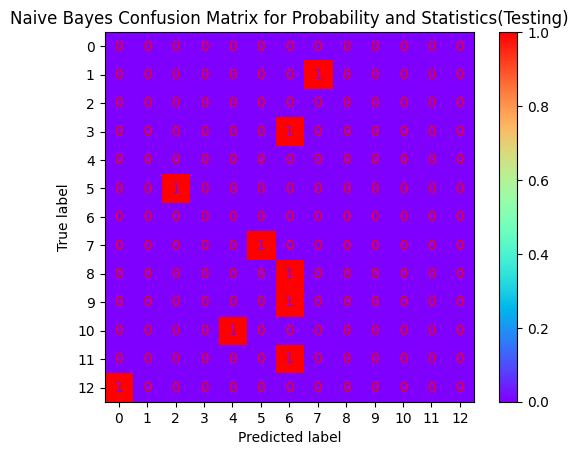

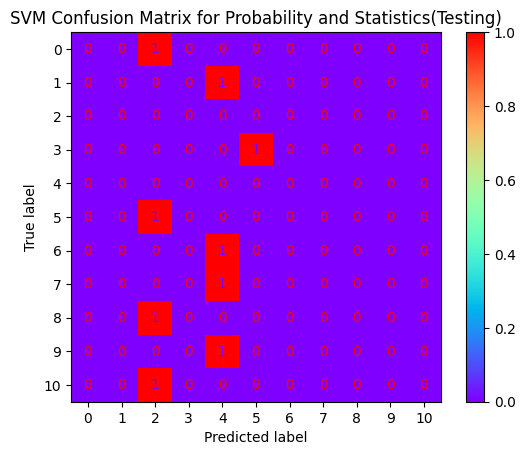

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import precision_recall_fscore_support, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Load the data
data = {
    'Interest': [8.4, 4.2, 10.0, 10.0, 6.8, 7.2, 8.2, 8.2, 6.4, 10.0, 6.4, 5.4, 6.2, 7.4, 7.6, 7.728571429, 7.385714286, 7.914285714, 7.528571429, 7.757142857, 7.142857143, 7.471428571, 8.0, 7.742857143, 7.114285714, 7.271428571, 7.9, 7.871428571, 7.2, 7.128571429],
    'Performance': [67, 59, 56, 71, 61, 36, 53, 73, 71, 64, 64, 26, 54, 61, 62, 60, 70, 77, 57, 55, 88, 67, 52, 72, 78, 63, 81, 86, 91, 71]
}

df = pd.DataFrame(data)

# Define features and target
X = df[['Interest']]  # Independent variable (Interest)
y = df['Performance']  # Dependent variable (Performance)

# Step 2: Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Step 3: Train Naive Bayes and SVM Models
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

svm_model = SVC(kernel='linear')
svm_model.fit(X_train, y_train)

# Step 4: Evaluate Naive Bayes
nb_predictions_test = nb_model.predict(X_test)

# Evaluate SVM
svm_predictions_test = svm_model.predict(X_test)

# Step 5: Confusion Matrix for both models
nb_conf_matrix = confusion_matrix(y_test, nb_predictions_test)
svm_conf_matrix = confusion_matrix(y_test, svm_predictions_test)

# Step 6: Sensitivity (Recall) and Specificity Calculation from the Confusion Matrix
def calculate_sensitivity_specificity(conf_matrix):
    # True positives, False negatives, False positives, True negatives
    TP = conf_matrix[1, 1]
    FN = conf_matrix[1, 0]
    FP = conf_matrix[0, 1]
    TN = conf_matrix[0, 0]

    # Sensitivity (Recall) = TP / (TP + FN)
    sensitivity = TP / (TP + FN) if (TP + FN) != 0 else 0
    # Specificity = TN / (TN + FP)
    specificity = TN / (TN + FP) if (TN + FP) != 0 else 0

    return sensitivity, specificity

# Naive Bayes Sensitivity and Specificity
nb_sensitivity, nb_specificity = calculate_sensitivity_specificity(nb_conf_matrix)
print(f"Naive Bayes Sensitivity: {nb_sensitivity}")
print(f"Naive Bayes Specificity: {nb_specificity}")

# SVM Sensitivity and Specificity
svm_sensitivity, svm_specificity = calculate_sensitivity_specificity(svm_conf_matrix)
print(f"SVM Sensitivity: {svm_sensitivity}")
print(f"SVM Specificity: {svm_specificity}")

# Step 7: Cross-Validation
nb_cv_scores = cross_val_score(nb_model, X, y, cv=3)  # 3-fold cross-validation
print(f"Naive Bayes Cross-Validation Scores: {nb_cv_scores}")
print(f"Naive Bayes Mean CV Score: {np.mean(nb_cv_scores)}")

svm_cv_scores = cross_val_score(svm_model, X, y, cv=3)  # 3-fold cross-validation
print(f"SVM Cross-Validation Scores: {svm_cv_scores}")
print(f"SVM Mean CV Score: {np.mean(svm_cv_scores)}")

# Confusion Matrix Plot (Naive Bayes)
disp_nb = ConfusionMatrixDisplay(confusion_matrix=nb_conf_matrix)
disp_nb.plot(cmap='rainbow')
plt.title('Naive Bayes Confusion Matrix for Probability and Statistics(Testing)')
plt.show()

# Confusion Matrix Plot (SVM)
disp_svm = ConfusionMatrixDisplay(confusion_matrix=svm_conf_matrix)
disp_svm.plot(cmap='rainbow')
plt.title('SVM Confusion Matrix for Probability and Statistics(Testing)')
plt.show()

Naive Bayes Sensitivity: 1.0
Naive Bayes Specificity: 1.0
SVM Sensitivity: 0
SVM Specificity: 1.0
Naive Bayes Cross-Validation Scores: [0.1 0.1 0. ]
Naive Bayes Mean CV Score: 0.06666666666666667
SVM Cross-Validation Scores: [0. 0. 0.]
SVM Mean CV Score: 0.0
The best model is: Naive Bayes
Predicted Values for 24 Leads:  [67 61 70 36 61 26 52 59 56 63 56 61 81 57 61 88 53 64 62 55 53]


/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_split.py:737: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_split.py:737: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(


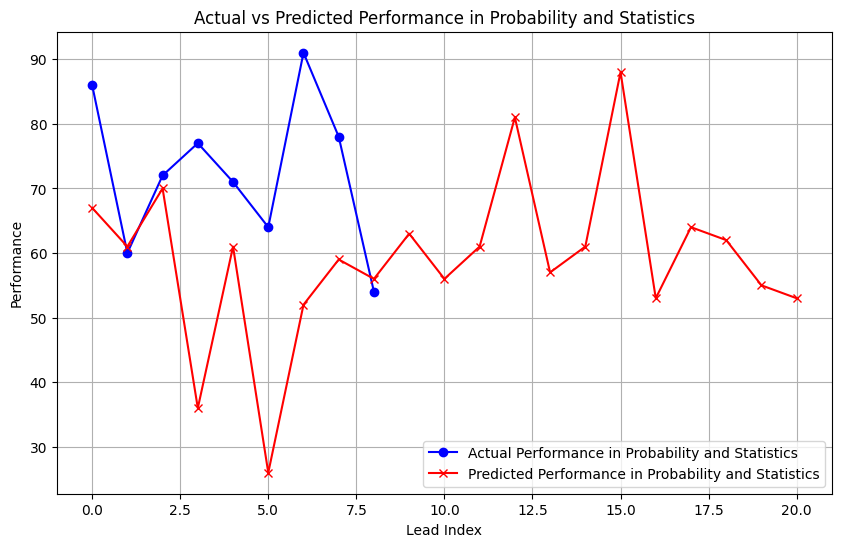

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import precision_recall_fscore_support, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Load the data
data = {
    'Interest': [8.4, 4.2, 10.0, 10.0, 6.8, 7.2, 8.2, 8.2, 6.4, 10.0, 6.4, 5.4, 6.2, 7.4, 7.6, 7.728571429, 7.385714286, 7.914285714, 7.528571429, 7.757142857, 7.142857143, 7.471428571, 8.0, 7.742857143, 7.114285714, 7.271428571, 7.9, 7.871428571, 7.2, 7.128571429],
    'Performance': [67, 59, 56, 71, 61, 36, 53, 73, 71, 64, 64, 26, 54, 61, 62, 60, 70, 77, 57, 55, 88, 67, 52, 72, 78, 63, 81, 86, 91, 71]
}

df = pd.DataFrame(data)

# Define features and target
X = df[['Interest']]  # Independent variable (Interest)
y = df['Performance']  # Dependent variable (Performance)

# Step 2: Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Step 3: Train Naive Bayes and SVM Models
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

svm_model = SVC(kernel='linear')
svm_model.fit(X_train, y_train)

# Step 4: Evaluate Naive Bayes
nb_predictions_test = nb_model.predict(X_train)

# Evaluate SVM
svm_predictions_test = svm_model.predict(X_train)

# Step 5: Confusion Matrix for both models
nb_conf_matrix = confusion_matrix(y_train, nb_predictions_train)
svm_conf_matrix = confusion_matrix(y_train, svm_predictions_train)

# Step 6: Sensitivity (Recall) and Specificity Calculation from the Confusion Matrix
def calculate_sensitivity_specificity(conf_matrix):
    # True positives, False negatives, False positives, True negatives
    TP = conf_matrix[1, 1]
    FN = conf_matrix[1, 0]
    FP = conf_matrix[0, 1]
    TN = conf_matrix[0, 0]

    # Sensitivity (Recall) = TP / (TP + FN)
    sensitivity = TP / (TP + FN) if (TP + FN) != 0 else 0
    # Specificity = TN / (TN + FP)
    specificity = TN / (TN + FP) if (TN + FP) != 0 else 0

    return sensitivity, specificity

# Naive Bayes Sensitivity and Specificity
nb_sensitivity, nb_specificity = calculate_sensitivity_specificity(nb_conf_matrix)
print(f"Naive Bayes Sensitivity: {nb_sensitivity}")
print(f"Naive Bayes Specificity: {nb_specificity}")

# SVM Sensitivity and Specificity
svm_sensitivity, svm_specificity = calculate_sensitivity_specificity(svm_conf_matrix)
print(f"SVM Sensitivity: {svm_sensitivity}")
print(f"SVM Specificity: {svm_specificity}")

# Step 7: Cross-Validation
nb_cv_scores = cross_val_score(nb_model, X, y, cv=3)  # 3-fold cross-validation
print(f"Naive Bayes Cross-Validation Scores: {nb_cv_scores}")
print(f"Naive Bayes Mean CV Score: {np.mean(nb_cv_scores)}")

svm_cv_scores = cross_val_score(svm_model, X, y, cv=3)  # 3-fold cross-validation
print(f"SVM Cross-Validation Scores: {svm_cv_scores}")
print(f"SVM Mean CV Score: {np.mean(svm_cv_scores)}")

# Compare the models and select the one with better performance (based on CV score)
best_model = nb_model if np.mean(nb_cv_scores) > np.mean(svm_cv_scores) else svm_model
print(f"The best model is: {'Naive Bayes' if best_model == nb_model else 'SVM'}")

# Step 8: Predict performance for 24 leads
predicted_values = best_model.predict(X_train[:24])
print("Predicted Values for 24 Leads: ", predicted_values)

# Step 9: Plot actual vs predicted values
plt.figure(figsize=(10,6))
plt.plot(y_test[:24].values, label="Actual Performance in Probability and Statistics", color='blue', marker='o')
plt.plot(predicted_values, label="Predicted Performance in Probability and Statistics", color='red', marker='x')
plt.title("Actual vs Predicted Performance in Probability and Statistics")
plt.xlabel("Lead Index")
plt.ylabel("Performance")
plt.legend()
plt.grid(True)
plt.show()

Data Analysis

Naive Bayes Train Accuracy:  0.5714285714285714
Naive Bayes Test Accuracy:  0.1111111111111111
SVM Train Accuracy:  0.2857142857142857
SVM Test Accuracy:  0.1111111111111111
Naive Bayes Classification Report (Test):
              precision    recall  f1-score   support

          33       0.00      0.00      0.00         0
          70       0.00      0.00      0.00         1
          71       0.00      0.00      0.00         2
          72       0.00      0.00      0.00         0
          75       0.00      0.00      0.00         3
          76       0.00      0.00      0.00         0
          77       0.50      1.00      0.67         1
          82       0.00      0.00      0.00         1
          84       0.00      0.00      0.00         1
          90       0.00      0.00      0.00         0

    accuracy                           0.11         9
   macro avg       0.05      0.10      0.07         9
weighted avg       0.06      0.11      0.07         9

SVM Classification Report

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.

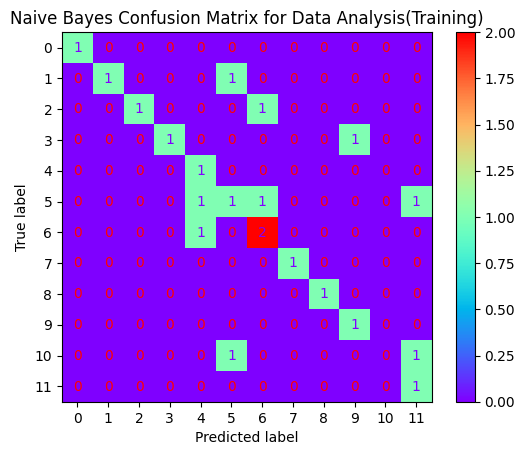

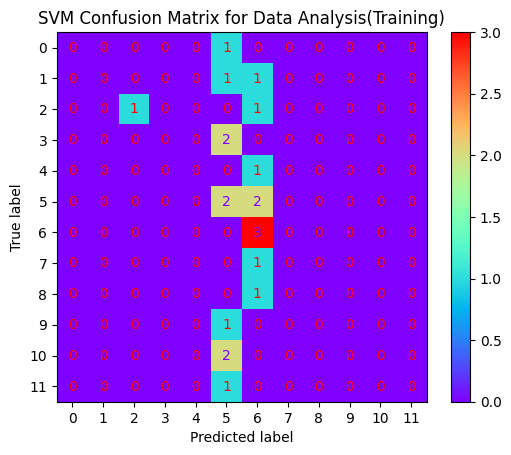

Fitting 2 folds for each of 12 candidates, totalling 24 fits


/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_split.py:737: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=2.
  warnings.warn(


Best parameters found:  {'C': 0.1, 'kernel': 'linear'}
Naive Bayes Accuracy on Large Dataset: 0.42444444444444446
Naive Bayes Time Taken on Large Dataset: 0.005910158157348633 seconds

SVM Accuracy on Large Dataset: 0.2644444444444444
SVM Time Taken on Large Dataset: 0.14928054809570312 seconds



In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import precision_recall_fscore_support, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import time
import seaborn as sns

# Step 1: Load the data
data = {
    'Interest': [7.6, 10, 9.8, 8.6, 9.6, 8.4, 10, 1, 10, 8.4, 7.2, 7.8, 8.8, 9.4, 8, 8.4, 10, 9.6, 9.8, 8.4, 8.4, 8.133333333, 8.314285714, 7.780952381, 8.733333333, 9.095238095, 9.161904762, 8.314285714, 8.876190476, 8.133333333],
    'Performance': [80, 90, 84, 65, 33, 77, 76, 66, 75, 75, 65, 77, 84, 71, 81, 82, 85, 70, 71, 72, 76, 76, 77, 77, 71, 85, 76, 75, 71, 66]
}

df = pd.DataFrame(data)

# Define features and target
X = df[['Interest']]  # Independent variable (Interest)
y = df['Performance']  # Dependent variable (Performance)

# Step 2: Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Step 3: Train Naive Bayes and SVM Models
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

svm_model = SVC(kernel='linear')
svm_model.fit(X_train, y_train)

# Step 4: Evaluate Naive Bayes
nb_predictions_train = nb_model.predict(X_train)
nb_predictions_test = nb_model.predict(X_test)

nb_train_accuracy = accuracy_score(y_train, nb_predictions_train)
nb_test_accuracy = accuracy_score(y_test, nb_predictions_test)

print("Naive Bayes Train Accuracy: ", nb_train_accuracy)
print("Naive Bayes Test Accuracy: ", nb_test_accuracy)

# Step 5: Evaluate SVM
svm_predictions_train = svm_model.predict(X_train)
svm_predictions_test = svm_model.predict(X_test)

svm_train_accuracy = accuracy_score(y_train, svm_predictions_train)
svm_test_accuracy = accuracy_score(y_test, svm_predictions_test)

print("SVM Train Accuracy: ", svm_train_accuracy)
print("SVM Test Accuracy: ", svm_test_accuracy)

# Classification report and performance metrics
print("Naive Bayes Classification Report (Test):")
print(classification_report(y_test, nb_predictions_test))

print("SVM Classification Report (Test):")
print(classification_report(y_test, svm_predictions_test))

# Confusion Matrix Plot (Naive Bayes)
nb_conf_matrix = confusion_matrix(y_train, nb_predictions_train)
disp_nb = ConfusionMatrixDisplay(confusion_matrix=nb_conf_matrix)
disp_nb.plot(cmap='rainbow')
plt.title('Naive Bayes Confusion Matrix for Data Analysis(Training)')
plt.show()

# Confusion Matrix Plot (SVM)
svm_conf_matrix = confusion_matrix(y_train, svm_predictions_train)
disp_svm = ConfusionMatrixDisplay(confusion_matrix=svm_conf_matrix)
disp_svm.plot(cmap='rainbow')
plt.title('SVM Confusion Matrix for Data Analysis(Training)')
plt.show()

# Step 6: Hyperparameter tuning using Grid Search
param_grid = {'C': [0.1, 1, 10, 100], 'kernel': ['linear', 'rbf', 'poly']}
grid_search = GridSearchCV(SVC(), param_grid, refit=True, verbose=1, cv=2)  # Reduce to 2 folds
grid_search.fit(X_train, y_train)

# Best parameters found through Grid Search
print("Best parameters found: ", grid_search.best_params_)

# Step 7: Simulate Larger Datasets and Perform Scalability Test
large_X = pd.DataFrame(np.tile(X.values, (100, 1)), columns=['Interest'])
large_y = np.tile(y.values, 100)

# Split the large dataset
X_train_large, X_test_large, y_train_large, y_test_large = train_test_split(large_X, large_y, test_size=0.3, random_state=42)

# Measure the time taken by Naive Bayes on large dataset
start_time = time.time()
nb_model.fit(X_train_large, y_train_large)
nb_large_predictions = nb_model.predict(X_test_large)
nb_large_accuracy = accuracy_score(y_test_large, nb_large_predictions)
nb_time_taken = time.time() - start_time

# Measure the time taken by SVM on large dataset
start_time = time.time()
svm_model.fit(X_train_large, y_train_large)
svm_large_predictions = svm_model.predict(X_test_large)
svm_large_accuracy = accuracy_score(y_test_large, svm_large_predictions)
svm_time_taken = time.time() - start_time

print(f"Naive Bayes Accuracy on Large Dataset: {nb_large_accuracy}")
print(f"Naive Bayes Time Taken on Large Dataset: {nb_time_taken} seconds\n")

print(f"SVM Accuracy on Large Dataset: {svm_large_accuracy}")
print(f"SVM Time Taken on Large Dataset: {svm_time_taken} seconds\n")

Naive Bayes Sensitivity: 0.0
Naive Bayes Specificity: 0
SVM Sensitivity: 0
SVM Specificity: 0
Naive Bayes Cross-Validation Scores: [0.1 0.2 0.1]
Naive Bayes Mean CV Score: 0.13333333333333333
SVM Cross-Validation Scores: [0.2 0.2 0.1]
SVM Mean CV Score: 0.16666666666666666


/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_split.py:737: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_split.py:737: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(


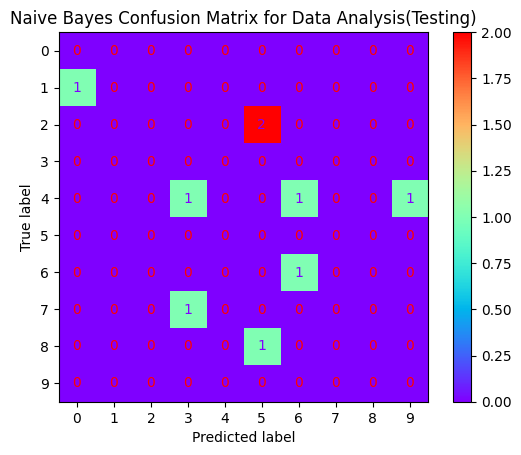

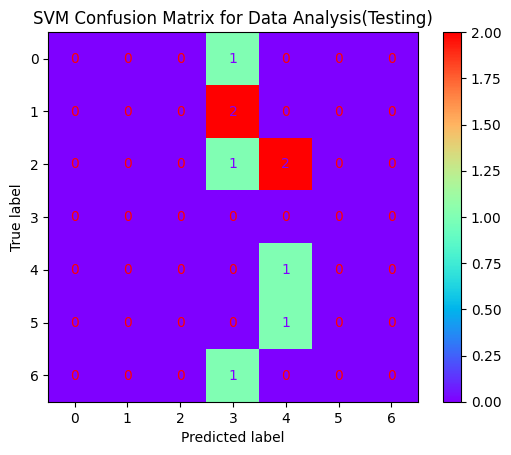

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import precision_recall_fscore_support, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Load the data
data = {
    'Interest': [7.6, 10, 9.8, 8.6, 9.6, 8.4, 10, 1, 10, 8.4, 7.2, 7.8, 8.8, 9.4, 8, 8.4, 10, 9.6, 9.8, 8.4, 8.4, 8.133333333, 8.314285714, 7.780952381, 8.733333333, 9.095238095, 9.161904762, 8.314285714, 8.876190476, 8.133333333],
    'Performance': [80, 90, 84, 65, 33, 77, 76, 66, 75, 75, 65, 77, 84, 71, 81, 82, 85, 70, 71, 72, 76, 76, 77, 77, 71, 85, 76, 75, 71, 66]
}

df = pd.DataFrame(data)

# Define features and target
X = df[['Interest']]  # Independent variable (Interest)
y = df['Performance']  # Dependent variable (Performance)

# Step 2: Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Step 3: Train Naive Bayes and SVM Models
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

svm_model = SVC(kernel='linear')
svm_model.fit(X_train, y_train)

# Step 4: Evaluate Naive Bayes
nb_predictions_test = nb_model.predict(X_test)

# Evaluate SVM
svm_predictions_test = svm_model.predict(X_test)

# Step 5: Confusion Matrix for both models
nb_conf_matrix = confusion_matrix(y_test, nb_predictions_test)
svm_conf_matrix = confusion_matrix(y_test, svm_predictions_test)

# Step 6: Sensitivity (Recall) and Specificity Calculation from the Confusion Matrix
def calculate_sensitivity_specificity(conf_matrix):
    # True positives, False negatives, False positives, True negatives
    TP = conf_matrix[1, 1]
    FN = conf_matrix[1, 0]
    FP = conf_matrix[0, 1]
    TN = conf_matrix[0, 0]

    # Sensitivity (Recall) = TP / (TP + FN)
    sensitivity = TP / (TP + FN) if (TP + FN) != 0 else 0
    # Specificity = TN / (TN + FP)
    specificity = TN / (TN + FP) if (TN + FP) != 0 else 0

    return sensitivity, specificity

# Naive Bayes Sensitivity and Specificity
nb_sensitivity, nb_specificity = calculate_sensitivity_specificity(nb_conf_matrix)
print(f"Naive Bayes Sensitivity: {nb_sensitivity}")
print(f"Naive Bayes Specificity: {nb_specificity}")

# SVM Sensitivity and Specificity
svm_sensitivity, svm_specificity = calculate_sensitivity_specificity(svm_conf_matrix)
print(f"SVM Sensitivity: {svm_sensitivity}")
print(f"SVM Specificity: {svm_specificity}")

# Step 7: Cross-Validation
nb_cv_scores = cross_val_score(nb_model, X, y, cv=3)  # 3-fold cross-validation
print(f"Naive Bayes Cross-Validation Scores: {nb_cv_scores}")
print(f"Naive Bayes Mean CV Score: {np.mean(nb_cv_scores)}")

svm_cv_scores = cross_val_score(svm_model, X, y, cv=3)  # 3-fold cross-validation
print(f"SVM Cross-Validation Scores: {svm_cv_scores}")
print(f"SVM Mean CV Score: {np.mean(svm_cv_scores)}")

# Confusion Matrix Plot (Naive Bayes)
disp_nb = ConfusionMatrixDisplay(confusion_matrix=nb_conf_matrix)
disp_nb.plot(cmap='rainbow')
plt.title('Naive Bayes Confusion Matrix for Data Analysis(Testing)')
plt.show()

# Confusion Matrix Plot (SVM)
disp_svm = ConfusionMatrixDisplay(confusion_matrix=svm_conf_matrix)
disp_svm.plot(cmap='rainbow')
plt.title('SVM Confusion Matrix for Data Analysis(Testing)')
plt.show()

Naive Bayes Sensitivity: 1.0
Naive Bayes Specificity: 1.0
SVM Sensitivity: 0
SVM Specificity: 0
Naive Bayes Cross-Validation Scores: [0.1 0.2 0.1]
Naive Bayes Mean CV Score: 0.13333333333333333
SVM Cross-Validation Scores: [0.2 0.2 0.1]
SVM Mean CV Score: 0.16666666666666666
The best model is: SVM
Predicted Values for 24 Leads:  [77 76 76 77 76 77 77 76 76 76 76 77 76 76 77 77 66 77 77 77 76]


/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_split.py:737: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_split.py:737: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(


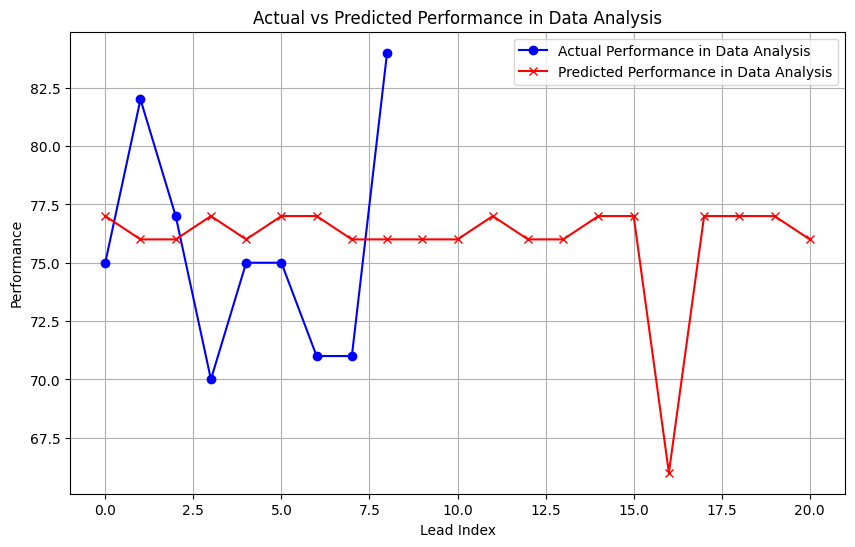

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import precision_recall_fscore_support, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Load the data
data = {
    'Interest': [7.6, 10, 9.8, 8.6, 9.6, 8.4, 10, 1, 10, 8.4, 7.2, 7.8, 8.8, 9.4, 8, 8.4, 10, 9.6, 9.8, 8.4, 8.4, 8.133333333, 8.314285714, 7.780952381, 8.733333333, 9.095238095, 9.161904762, 8.314285714, 8.876190476, 8.133333333],
    'Performance': [80, 90, 84, 65, 33, 77, 76, 66, 75, 75, 65, 77, 84, 71, 81, 82, 85, 70, 71, 72, 76, 76, 77, 77, 71, 85, 76, 75, 71, 66]
}

df = pd.DataFrame(data)

# Define features and target
X = df[['Interest']]  # Independent variable (Interest)
y = df['Performance']  # Dependent variable (Performance)

# Step 2: Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Step 3: Train Naive Bayes and SVM Models
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

svm_model = SVC(kernel='linear')
svm_model.fit(X_train, y_train)

# Step 4: Evaluate Naive Bayes
nb_predictions_test = nb_model.predict(X_train)

# Evaluate SVM
svm_predictions_test = svm_model.predict(X_train)

# Step 5: Confusion Matrix for both models
nb_conf_matrix = confusion_matrix(y_train, nb_predictions_train)
svm_conf_matrix = confusion_matrix(y_train, svm_predictions_train)

# Step 6: Sensitivity (Recall) and Specificity Calculation from the Confusion Matrix
def calculate_sensitivity_specificity(conf_matrix):
    # True positives, False negatives, False positives, True negatives
    TP = conf_matrix[1, 1]
    FN = conf_matrix[1, 0]
    FP = conf_matrix[0, 1]
    TN = conf_matrix[0, 0]

    # Sensitivity (Recall) = TP / (TP + FN)
    sensitivity = TP / (TP + FN) if (TP + FN) != 0 else 0
    # Specificity = TN / (TN + FP)
    specificity = TN / (TN + FP) if (TN + FP) != 0 else 0

    return sensitivity, specificity

# Naive Bayes Sensitivity and Specificity
nb_sensitivity, nb_specificity = calculate_sensitivity_specificity(nb_conf_matrix)
print(f"Naive Bayes Sensitivity: {nb_sensitivity}")
print(f"Naive Bayes Specificity: {nb_specificity}")

# SVM Sensitivity and Specificity
svm_sensitivity, svm_specificity = calculate_sensitivity_specificity(svm_conf_matrix)
print(f"SVM Sensitivity: {svm_sensitivity}")
print(f"SVM Specificity: {svm_specificity}")

# Step 7: Cross-Validation
nb_cv_scores = cross_val_score(nb_model, X, y, cv=3)  # 3-fold cross-validation
print(f"Naive Bayes Cross-Validation Scores: {nb_cv_scores}")
print(f"Naive Bayes Mean CV Score: {np.mean(nb_cv_scores)}")

svm_cv_scores = cross_val_score(svm_model, X, y, cv=3)  # 3-fold cross-validation
print(f"SVM Cross-Validation Scores: {svm_cv_scores}")
print(f"SVM Mean CV Score: {np.mean(svm_cv_scores)}")

# Compare the models and select the one with better performance (based on CV score)
best_model = nb_model if np.mean(nb_cv_scores) > np.mean(svm_cv_scores) else svm_model
print(f"The best model is: {'Naive Bayes' if best_model == nb_model else 'SVM'}")

# Step 8: Predict performance for 24 leads
predicted_values = best_model.predict(X_train[:24])
print("Predicted Values for 24 Leads: ", predicted_values)

# Step 9: Plot actual vs predicted values
plt.figure(figsize=(10,6))
plt.plot(y_test[:24].values, label="Actual Performance in Data Analysis", color='blue', marker='o')
plt.plot(predicted_values, label="Predicted Performance in Data Analysis", color='red', marker='x')
plt.title("Actual vs Predicted Performance in Data Analysis")
plt.xlabel("Lead Index")
plt.ylabel("Performance")
plt.legend()
plt.grid(True)
plt.show()

Statistical Computing

Naive Bayes Train Accuracy:  0.7619047619047619
Naive Bayes Test Accuracy:  0.1111111111111111
SVM Train Accuracy:  0.23809523809523808
SVM Test Accuracy:  0.0
Naive Bayes Classification Report (Test):
              precision    recall  f1-score   support

          56       0.00      0.00      0.00         1
          61       0.00      0.00      0.00         0
          62       0.00      0.00      0.00         1
          63       0.00      0.00      0.00         1
          64       0.00      0.00      0.00         1
          66       0.00      0.00      0.00         0
          68       0.00      0.00      0.00         1
          70       0.00      0.00      0.00         2
          72       0.00      0.00      0.00         0
          74       0.50      1.00      0.67         1
          75       0.00      0.00      0.00         1

    accuracy                           0.11         9
   macro avg       0.05      0.09      0.06         9
weighted avg       0.06      0.11      0

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.

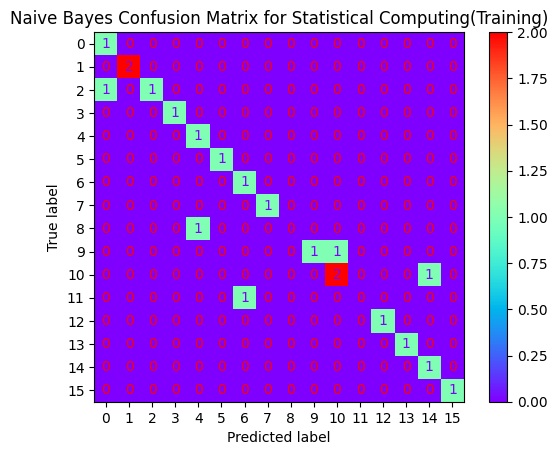

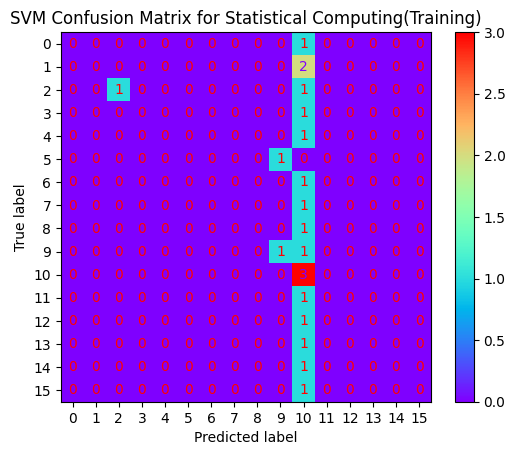

Fitting 2 folds for each of 12 candidates, totalling 24 fits
Best parameters found:  {'C': 0.1, 'kernel': 'linear'}


/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_split.py:737: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=2.
  warnings.warn(


Naive Bayes Accuracy on Large Dataset: 0.52
Naive Bayes Time Taken on Large Dataset: 0.005966663360595703 seconds

SVM Accuracy on Large Dataset: 0.22111111111111112
SVM Time Taken on Large Dataset: 0.16744375228881836 seconds



In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import precision_recall_fscore_support, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import time
import seaborn as sns

# Step 1: Load the data
data = {
    'Interest': [8.4, 4.6, 10, 7.4, 9.4, 7.2, 8.4, 1, 10, 8, 8, 7.8, 9.8, 9.6, 9.4, 10, 9.8, 9.8, 9.8, 8, 6.2, 8.019047619, 7.895238095, 8.076190476, 8.152380952, 7.971428571, 8.542857143, 8.685714286, 7.476190476, 8.20952381],
    'Performance': [62, 70, 74, 70, 85, 72, 50, 62, 68, 70, 68, 61, 62, 86, 72, 74, 73, 56, 66, 64, 65, 61, 77, 70, 75, 67, 63, 64, 63, 72]
}

df = pd.DataFrame(data)

# Define features and target
X = df[['Interest']]  # Independent variable (Interest)
y = df['Performance']  # Dependent variable (Performance)

# Step 2: Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Step 3: Train Naive Bayes and SVM Models
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

svm_model = SVC(kernel='linear')
svm_model.fit(X_train, y_train)

# Step 4: Evaluate Naive Bayes
nb_predictions_train = nb_model.predict(X_train)
nb_predictions_test = nb_model.predict(X_test)

nb_train_accuracy = accuracy_score(y_train, nb_predictions_train)
nb_test_accuracy = accuracy_score(y_test, nb_predictions_test)

print("Naive Bayes Train Accuracy: ", nb_train_accuracy)
print("Naive Bayes Test Accuracy: ", nb_test_accuracy)

# Step 5: Evaluate SVM
svm_predictions_train = svm_model.predict(X_train)
svm_predictions_test = svm_model.predict(X_test)

svm_train_accuracy = accuracy_score(y_train, svm_predictions_train)
svm_test_accuracy = accuracy_score(y_test, svm_predictions_test)

print("SVM Train Accuracy: ", svm_train_accuracy)
print("SVM Test Accuracy: ", svm_test_accuracy)

# Classification report and performance metrics
print("Naive Bayes Classification Report (Test):")
print(classification_report(y_test, nb_predictions_test))

print("SVM Classification Report (Test):")
print(classification_report(y_test, svm_predictions_test))

# Confusion Matrix Plot (Naive Bayes)
nb_conf_matrix = confusion_matrix(y_train, nb_predictions_train)
disp_nb = ConfusionMatrixDisplay(confusion_matrix=nb_conf_matrix)
disp_nb.plot(cmap='rainbow')
plt.title('Naive Bayes Confusion Matrix for Statistical Computing(Training)')
plt.show()

# Confusion Matrix Plot (SVM)
svm_conf_matrix = confusion_matrix(y_train, svm_predictions_train)
disp_svm = ConfusionMatrixDisplay(confusion_matrix=svm_conf_matrix)
disp_svm.plot(cmap='rainbow')
plt.title('SVM Confusion Matrix for Statistical Computing(Training)')
plt.show()

# Step 6: Hyperparameter tuning using Grid Search
param_grid = {'C': [0.1, 1, 10, 100], 'kernel': ['linear', 'rbf', 'poly']}
grid_search = GridSearchCV(SVC(), param_grid, refit=True, verbose=1, cv=2)  # Reduce to 2 folds
grid_search.fit(X_train, y_train)

# Best parameters found through Grid Search
print("Best parameters found: ", grid_search.best_params_)

# Step 7: Simulate Larger Datasets and Perform Scalability Test
large_X = pd.DataFrame(np.tile(X.values, (100, 1)), columns=['Interest'])
large_y = np.tile(y.values, 100)

# Split the large dataset
X_train_large, X_test_large, y_train_large, y_test_large = train_test_split(large_X, large_y, test_size=0.3, random_state=42)

# Measure the time taken by Naive Bayes on large dataset
start_time = time.time()
nb_model.fit(X_train_large, y_train_large)
nb_large_predictions = nb_model.predict(X_test_large)
nb_large_accuracy = accuracy_score(y_test_large, nb_large_predictions)
nb_time_taken = time.time() - start_time

# Measure the time taken by SVM on large dataset
start_time = time.time()
svm_model.fit(X_train_large, y_train_large)
svm_large_predictions = svm_model.predict(X_test_large)
svm_large_accuracy = accuracy_score(y_test_large, svm_large_predictions)
svm_time_taken = time.time() - start_time

print(f"Naive Bayes Accuracy on Large Dataset: {nb_large_accuracy}")
print(f"Naive Bayes Time Taken on Large Dataset: {nb_time_taken} seconds\n")

print(f"SVM Accuracy on Large Dataset: {svm_large_accuracy}")
print(f"SVM Time Taken on Large Dataset: {svm_time_taken} seconds\n")

Naive Bayes Sensitivity: 0
Naive Bayes Specificity: 0
SVM Sensitivity: 0
SVM Specificity: 0
Naive Bayes Cross-Validation Scores: [0.  0.1 0.1]
Naive Bayes Mean CV Score: 0.06666666666666667
SVM Cross-Validation Scores: [0.  0.1 0.2]
SVM Mean CV Score: 0.10000000000000002


/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_split.py:737: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_split.py:737: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(


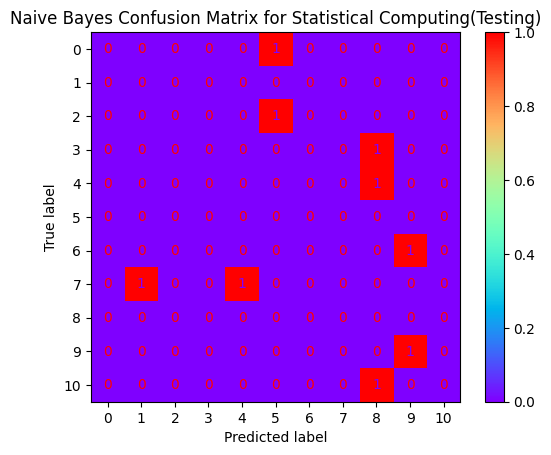

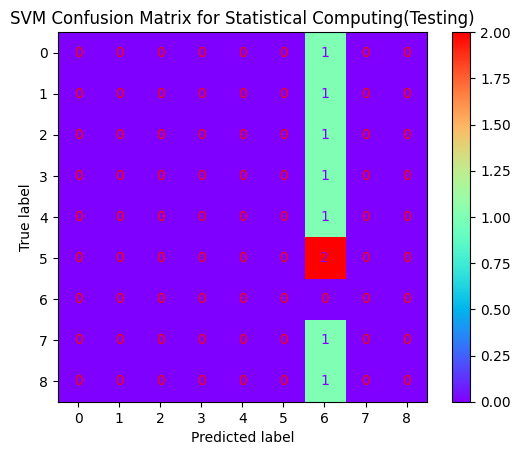

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import precision_recall_fscore_support, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Load the data
data = {
    'Interest': [8.4, 4.6, 10, 7.4, 9.4, 7.2, 8.4, 1, 10, 8, 8, 7.8, 9.8, 9.6, 9.4, 10, 9.8, 9.8, 9.8, 8, 6.2, 8.019047619, 7.895238095, 8.076190476, 8.152380952, 7.971428571, 8.542857143, 8.685714286, 7.476190476, 8.20952381],
    'Performance': [62, 70, 74, 70, 85, 72, 50, 62, 68, 70, 68, 61, 62, 86, 72, 74, 73, 56, 66, 64, 65, 61, 77, 70, 75, 67, 63, 64, 63, 72]
}

df = pd.DataFrame(data)

# Define features and target
X = df[['Interest']]  # Independent variable (Interest)
y = df['Performance']  # Dependent variable (Performance)

# Step 2: Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Step 3: Train Naive Bayes and SVM Models
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

svm_model = SVC(kernel='linear')
svm_model.fit(X_train, y_train)

# Step 4: Evaluate Naive Bayes
nb_predictions_test = nb_model.predict(X_test)

# Evaluate SVM
svm_predictions_test = svm_model.predict(X_test)

# Step 5: Confusion Matrix for both models
nb_conf_matrix = confusion_matrix(y_test, nb_predictions_test)
svm_conf_matrix = confusion_matrix(y_test, svm_predictions_test)

# Step 6: Sensitivity (Recall) and Specificity Calculation from the Confusion Matrix
def calculate_sensitivity_specificity(conf_matrix):
    # True positives, False negatives, False positives, True negatives
    TP = conf_matrix[1, 1]
    FN = conf_matrix[1, 0]
    FP = conf_matrix[0, 1]
    TN = conf_matrix[0, 0]

    # Sensitivity (Recall) = TP / (TP + FN)
    sensitivity = TP / (TP + FN) if (TP + FN) != 0 else 0
    # Specificity = TN / (TN + FP)
    specificity = TN / (TN + FP) if (TN + FP) != 0 else 0

    return sensitivity, specificity

# Naive Bayes Sensitivity and Specificity
nb_sensitivity, nb_specificity = calculate_sensitivity_specificity(nb_conf_matrix)
print(f"Naive Bayes Sensitivity: {nb_sensitivity}")
print(f"Naive Bayes Specificity: {nb_specificity}")

# SVM Sensitivity and Specificity
svm_sensitivity, svm_specificity = calculate_sensitivity_specificity(svm_conf_matrix)
print(f"SVM Sensitivity: {svm_sensitivity}")
print(f"SVM Specificity: {svm_specificity}")

# Step 7: Cross-Validation
nb_cv_scores = cross_val_score(nb_model, X, y, cv=3)  # 3-fold cross-validation
print(f"Naive Bayes Cross-Validation Scores: {nb_cv_scores}")
print(f"Naive Bayes Mean CV Score: {np.mean(nb_cv_scores)}")

svm_cv_scores = cross_val_score(svm_model, X, y, cv=3)  # 3-fold cross-validation
print(f"SVM Cross-Validation Scores: {svm_cv_scores}")
print(f"SVM Mean CV Score: {np.mean(svm_cv_scores)}")

# Confusion Matrix Plot (Naive Bayes)
disp_nb = ConfusionMatrixDisplay(confusion_matrix=nb_conf_matrix)
disp_nb.plot(cmap='rainbow')
plt.title('Naive Bayes Confusion Matrix for Statistical Computing(Testing)')
plt.show()

# Confusion Matrix Plot (SVM)
disp_svm = ConfusionMatrixDisplay(confusion_matrix=svm_conf_matrix)
disp_svm.plot(cmap='rainbow')
plt.title('SVM Confusion Matrix for Statistical Computing(Testing)')
plt.show()

Naive Bayes Sensitivity: 1.0
Naive Bayes Specificity: 1.0
SVM Sensitivity: 0
SVM Specificity: 0
Naive Bayes Cross-Validation Scores: [0.  0.1 0.1]
Naive Bayes Mean CV Score: 0.06666666666666667
SVM Cross-Validation Scores: [0.  0.1 0.2]
SVM Mean CV Score: 0.10000000000000002
The best model is: SVM
Predicted Values for 24 Leads:  [72 72 72 72 72 72 72 70 72 72 72 72 72 72 72 70 62 72 72 72 72]


/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_split.py:737: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_split.py:737: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(


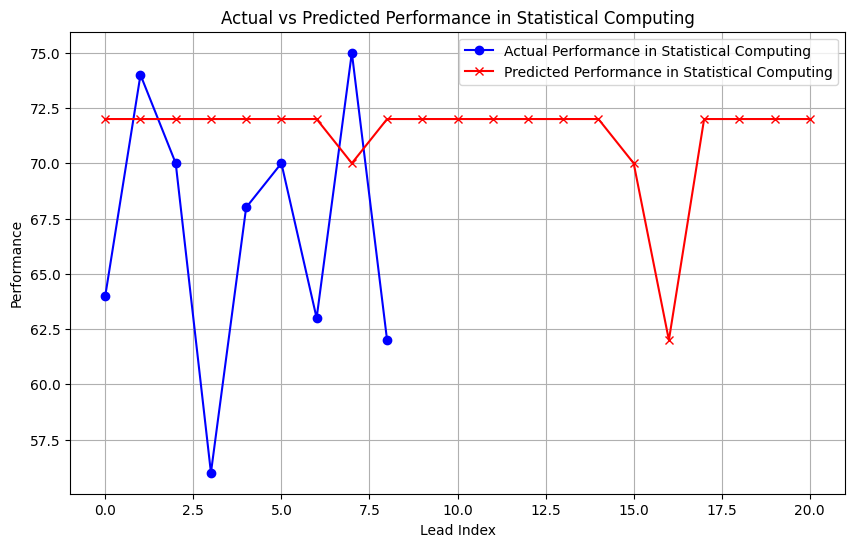

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import precision_recall_fscore_support, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Load the data
data = {
    'Interest': [8.4, 4.6, 10, 7.4, 9.4, 7.2, 8.4, 1, 10, 8, 8, 7.8, 9.8, 9.6, 9.4, 10, 9.8, 9.8, 9.8, 8, 6.2, 8.019047619, 7.895238095, 8.076190476, 8.152380952, 7.971428571, 8.542857143, 8.685714286, 7.476190476, 8.20952381],
    'Performance': [62, 70, 74, 70, 85, 72, 50, 62, 68, 70, 68, 61, 62, 86, 72, 74, 73, 56, 66, 64, 65, 61, 77, 70, 75, 67, 63, 64, 63, 72]
}

df = pd.DataFrame(data)

# Define features and target
X = df[['Interest']]  # Independent variable (Interest)
y = df['Performance']  # Dependent variable (Performance)

# Step 2: Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Step 3: Train Naive Bayes and SVM Models
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

svm_model = SVC(kernel='linear')
svm_model.fit(X_train, y_train)

# Step 4: Evaluate Naive Bayes
nb_predictions_test = nb_model.predict(X_train)

# Evaluate SVM
svm_predictions_test = svm_model.predict(X_train)

# Step 5: Confusion Matrix for both models
nb_conf_matrix = confusion_matrix(y_train, nb_predictions_train)
svm_conf_matrix = confusion_matrix(y_train, svm_predictions_train)

# Step 6: Sensitivity (Recall) and Specificity Calculation from the Confusion Matrix
def calculate_sensitivity_specificity(conf_matrix):
    # True positives, False negatives, False positives, True negatives
    TP = conf_matrix[1, 1]
    FN = conf_matrix[1, 0]
    FP = conf_matrix[0, 1]
    TN = conf_matrix[0, 0]

    # Sensitivity (Recall) = TP / (TP + FN)
    sensitivity = TP / (TP + FN) if (TP + FN) != 0 else 0
    # Specificity = TN / (TN + FP)
    specificity = TN / (TN + FP) if (TN + FP) != 0 else 0

    return sensitivity, specificity

# Naive Bayes Sensitivity and Specificity
nb_sensitivity, nb_specificity = calculate_sensitivity_specificity(nb_conf_matrix)
print(f"Naive Bayes Sensitivity: {nb_sensitivity}")
print(f"Naive Bayes Specificity: {nb_specificity}")

# SVM Sensitivity and Specificity
svm_sensitivity, svm_specificity = calculate_sensitivity_specificity(svm_conf_matrix)
print(f"SVM Sensitivity: {svm_sensitivity}")
print(f"SVM Specificity: {svm_specificity}")

# Step 7: Cross-Validation
nb_cv_scores = cross_val_score(nb_model, X, y, cv=3)  # 3-fold cross-validation
print(f"Naive Bayes Cross-Validation Scores: {nb_cv_scores}")
print(f"Naive Bayes Mean CV Score: {np.mean(nb_cv_scores)}")

svm_cv_scores = cross_val_score(svm_model, X, y, cv=3)  # 3-fold cross-validation
print(f"SVM Cross-Validation Scores: {svm_cv_scores}")
print(f"SVM Mean CV Score: {np.mean(svm_cv_scores)}")

# Compare the models and select the one with better performance (based on CV score)
best_model = nb_model if np.mean(nb_cv_scores) > np.mean(svm_cv_scores) else svm_model
print(f"The best model is: {'Naive Bayes' if best_model == nb_model else 'SVM'}")

# Step 8: Predict performance for 24 leads
predicted_values = best_model.predict(X_train[:24])
print("Predicted Values for 24 Leads: ", predicted_values)

# Step 9: Plot actual vs predicted values
plt.figure(figsize=(10,6))
plt.plot(y_test[:24].values, label="Actual Performance in Statistical Computing", color='blue', marker='o')
plt.plot(predicted_values, label="Predicted Performance in Statistical Computing", color='red', marker='x')
plt.title("Actual vs Predicted Performance in Statistical Computing")
plt.xlabel("Lead Index")
plt.ylabel("Performance")
plt.legend()
plt.grid(True)
plt.show()

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_

Naive Bayes Weighted F1-score: 0.1333
SVM Weighted F1-score: 0.1111
Naive Bayes Classification Report (Test):
              precision    recall  f1-score   support

          78       0.00      0.00      0.00         0
          79       0.00      0.00      0.00         1
          80       0.00      0.00      0.00         1
          82       0.00      0.00      0.00         1
          83       0.50      0.33      0.40         3
          84       0.00      0.00      0.00         0
          87       0.00      0.00      0.00         1
          91       0.00      0.00      0.00         1
          92       0.00      0.00      0.00         1

    accuracy                           0.11         9
   macro avg       0.06      0.04      0.04         9
weighted avg       0.17      0.11      0.13         9

SVM Classification Report (Test):
              precision    recall  f1-score   support

          78       0.00      0.00      0.00         0
          79       0.00      0.00      0.0

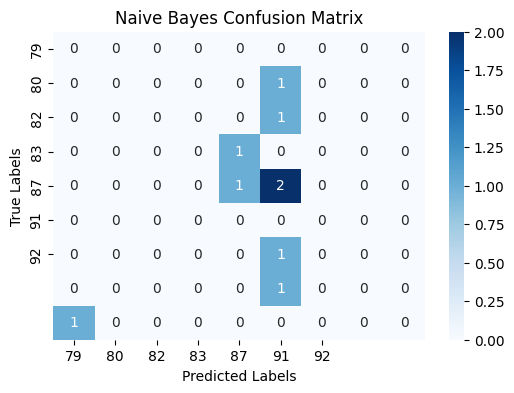

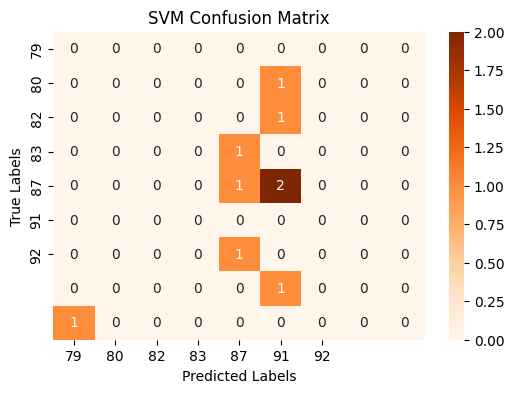

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import precision_recall_fscore_support, ConfusionMatrixDisplay

# Step 1: Load the data
data = {
    'Interest': [8.2, 4.6, 10, 10, 7.8, 8.8, 8, 7.8, 7.2, 10, 6.2, 4.8, 6.8, 7, 7.742857143, 7.085714286, 7.7,
                 7.228571429, 7.3, 6.857142857, 7.871428571, 7.342857143, 7.4, 8.171428571, 6.9, 7.485714286,
                 7.957142857, 7.942857143, 7.457142857, 7.214285714],
    'Performance': [88, 88, 78, 78, 82, 77, 94, 90, 91, 92, 93, 78, 80, 88, 81, 79, 68, 83, 73, 84, 83, 83,
                    85, 87, 83, 83, 84, 83, 82, 84]
}

df = pd.DataFrame(data)

# Define features and target
X = df[['Interest']]
y = df['Performance']

# Step 2: Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Step 3: Train Naive Bayes and SVM Models
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

svm_model = SVC(kernel='linear')
svm_model.fit(X_train, y_train)

# Step 4: Evaluate Naive Bayes
nb_predictions_test = nb_model.predict(X_test)
nb_predictions_train = nb_model.predict(X_train)
nb_f1_weighted = precision_recall_fscore_support(y_test, nb_predictions_test, average='weighted')[2]
print(f"Naive Bayes Weighted F1-score: {nb_f1_weighted:.4f}")

# Step 5: Evaluate SVM
svm_predictions_test = svm_model.predict(X_test)
svm_predictions_train = svm_model.predict(X_train)
svm_f1_weighted = precision_recall_fscore_support(y_test, svm_predictions_test, average='weighted')[2]
print(f"SVM Weighted F1-score: {svm_f1_weighted:.4f}")

# Classification report
print("Naive Bayes Classification Report (Test):")
print(classification_report(y_test, nb_predictions_test))

print("SVM Classification Report (Test):")
print(classification_report(y_test, svm_predictions_test))

# Step 6: Confusion Matrix Plot (Naive Bayes)
plt.figure(figsize=(6, 4))
nb_conf_matrix = confusion_matrix(y_test, nb_predictions_test)
sns.heatmap(nb_conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Naive Bayes Confusion Matrix')
plt.show()

# Confusion Matrix Plot (SVM)
plt.figure(figsize=(6, 4))
svm_conf_matrix = confusion_matrix(y_test, svm_predictions_test)
sns.heatmap(svm_conf_matrix, annot=True, fmt='d', cmap='Oranges', xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('SVM Confusion Matrix')
plt.show()

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_

Naive Bayes Weighted F1-score: 0.0000
SVM Weighted F1-score: 0.0000
Naive Bayes Classification Report (Test):
              precision    recall  f1-score   support

          36       0.00      0.00      0.00       0.0
          54       0.00      0.00      0.00       1.0
          56       0.00      0.00      0.00       0.0
          60       0.00      0.00      0.00       1.0
          61       0.00      0.00      0.00       0.0
          64       0.00      0.00      0.00       1.0
          67       0.00      0.00      0.00       0.0
          71       0.00      0.00      0.00       1.0
          72       0.00      0.00      0.00       1.0
          77       0.00      0.00      0.00       1.0
          78       0.00      0.00      0.00       1.0
          86       0.00      0.00      0.00       1.0
          91       0.00      0.00      0.00       1.0

    accuracy                           0.00       9.0
   macro avg       0.00      0.00      0.00       9.0
weighted avg       0.00 

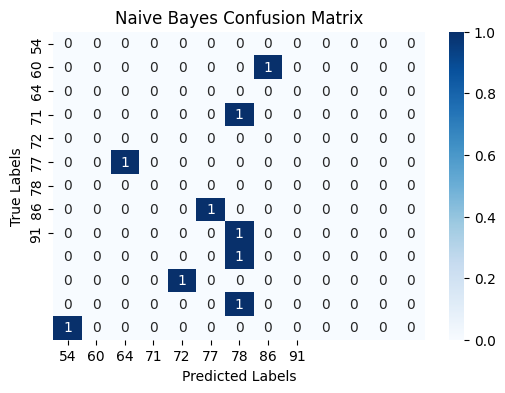

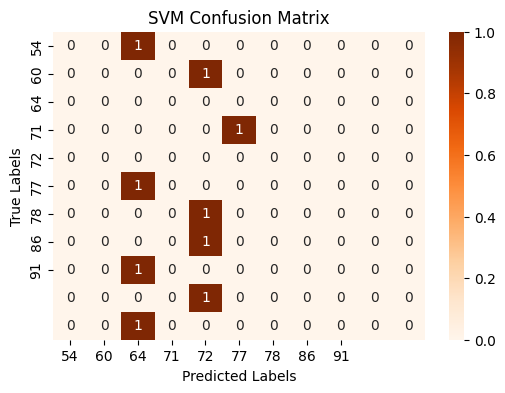

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import precision_recall_fscore_support, ConfusionMatrixDisplay

# Step 1: Load the data
data = {
    'Interest': [8.4, 4.2, 10.0, 10.0, 6.8, 7.2, 8.2, 8.2, 6.4, 10.0, 6.4, 5.4, 6.2, 7.4, 7.6, 7.728571429, 7.385714286, 7.914285714, 7.528571429, 7.757142857, 7.142857143, 7.471428571, 8.0, 7.742857143, 7.114285714, 7.271428571, 7.9, 7.871428571, 7.2, 7.128571429],
    'Performance': [67, 59, 56, 71, 61, 36, 53, 73, 71, 64, 64, 26, 54, 61, 62, 60, 70, 77, 57, 55, 88, 67, 52, 72, 78, 63, 81, 86, 91, 71]
}

df = pd.DataFrame(data)

# Define features and target
X = df[['Interest']]
y = df['Performance']

# Step 2: Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Step 3: Train Naive Bayes and SVM Models
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

svm_model = SVC(kernel='linear')
svm_model.fit(X_train, y_train)

# Step 4: Evaluate Naive Bayes
nb_predictions_test = nb_model.predict(X_test)
nb_predictions_train = nb_model.predict(X_train)
nb_f1_weighted = precision_recall_fscore_support(y_test, nb_predictions_test, average='weighted')[2]
print(f"Naive Bayes Weighted F1-score: {nb_f1_weighted:.4f}")

# Step 5: Evaluate SVM
svm_predictions_test = svm_model.predict(X_test)
svm_predictions_train = svm_model.predict(X_train)
svm_f1_weighted = precision_recall_fscore_support(y_test, svm_predictions_test, average='weighted')[2]
print(f"SVM Weighted F1-score: {svm_f1_weighted:.4f}")

# Classification report
print("Naive Bayes Classification Report (Test):")
print(classification_report(y_test, nb_predictions_test))

print("SVM Classification Report (Test):")
print(classification_report(y_test, svm_predictions_test))

# Step 6: Confusion Matrix Plot (Naive Bayes)
plt.figure(figsize=(6, 4))
nb_conf_matrix = confusion_matrix(y_test, nb_predictions_test)
sns.heatmap(nb_conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Naive Bayes Confusion Matrix')
plt.show()

# Confusion Matrix Plot (SVM)
plt.figure(figsize=(6, 4))
svm_conf_matrix = confusion_matrix(y_test, svm_predictions_test)
sns.heatmap(svm_conf_matrix, annot=True, fmt='d', cmap='Oranges', xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('SVM Confusion Matrix')
plt.show()

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_

Naive Bayes Weighted F1-score: 0.0741
SVM Weighted F1-score: 0.0444
Naive Bayes Classification Report (Test):
              precision    recall  f1-score   support

          33       0.00      0.00      0.00         0
          70       0.00      0.00      0.00         1
          71       0.00      0.00      0.00         2
          72       0.00      0.00      0.00         0
          75       0.00      0.00      0.00         3
          76       0.00      0.00      0.00         0
          77       0.50      1.00      0.67         1
          82       0.00      0.00      0.00         1
          84       0.00      0.00      0.00         1
          90       0.00      0.00      0.00         0

    accuracy                           0.11         9
   macro avg       0.05      0.10      0.07         9
weighted avg       0.06      0.11      0.07         9

SVM Classification Report (Test):
              precision    recall  f1-score   support

          70       0.00      0.00      0.0

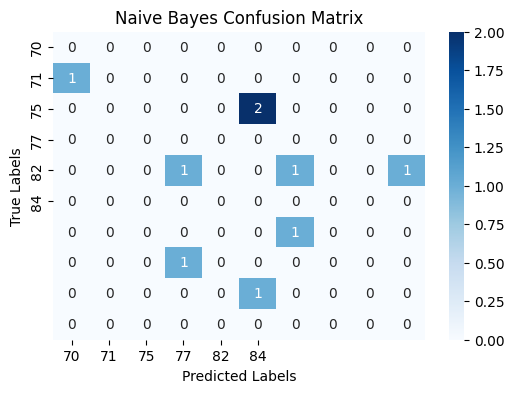

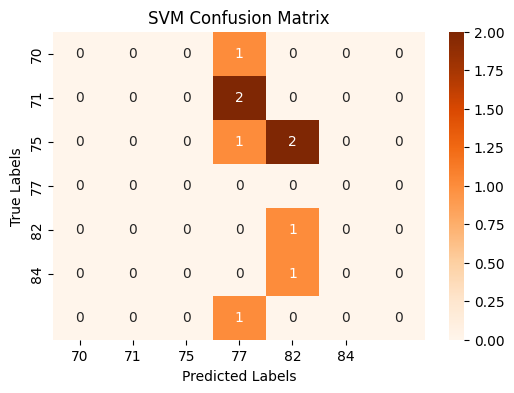

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import precision_recall_fscore_support, ConfusionMatrixDisplay

# Step 1: Load the data
data = {
    'Interest': [7.6, 10, 9.8, 8.6, 9.6, 8.4, 10, 1, 10, 8.4, 7.2, 7.8, 8.8, 9.4, 8, 8.4, 10, 9.6, 9.8, 8.4, 8.4, 8.133333333, 8.314285714, 7.780952381, 8.733333333, 9.095238095, 9.161904762, 8.314285714, 8.876190476, 8.133333333],
    'Performance': [80, 90, 84, 65, 33, 77, 76, 66, 75, 75, 65, 77, 84, 71, 81, 82, 85, 70, 71, 72, 76, 76, 77, 77, 71, 85, 76, 75, 71, 66]
}

df = pd.DataFrame(data)

# Define features and target
X = df[['Interest']]
y = df['Performance']

# Step 2: Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Step 3: Train Naive Bayes and SVM Models
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

svm_model = SVC(kernel='linear')
svm_model.fit(X_train, y_train)

# Step 4: Evaluate Naive Bayes
nb_predictions_test = nb_model.predict(X_test)
nb_predictions_train = nb_model.predict(X_train)
nb_f1_weighted = precision_recall_fscore_support(y_test, nb_predictions_test, average='weighted')[2]
print(f"Naive Bayes Weighted F1-score: {nb_f1_weighted:.4f}")

# Step 5: Evaluate SVM
svm_predictions_test = svm_model.predict(X_test)
svm_predictions_train = svm_model.predict(X_train)
svm_f1_weighted = precision_recall_fscore_support(y_test, svm_predictions_test, average='weighted')[2]
print(f"SVM Weighted F1-score: {svm_f1_weighted:.4f}")

# Classification report
print("Naive Bayes Classification Report (Test):")
print(classification_report(y_test, nb_predictions_test))

print("SVM Classification Report (Test):")
print(classification_report(y_test, svm_predictions_test))

# Step 6: Confusion Matrix Plot (Naive Bayes)
plt.figure(figsize=(6, 4))
nb_conf_matrix = confusion_matrix(y_test, nb_predictions_test)
sns.heatmap(nb_conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Naive Bayes Confusion Matrix')
plt.show()

# Confusion Matrix Plot (SVM)
plt.figure(figsize=(6, 4))
svm_conf_matrix = confusion_matrix(y_test, svm_predictions_test)
sns.heatmap(svm_conf_matrix, annot=True, fmt='d', cmap='Oranges', xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('SVM Confusion Matrix')
plt.show()

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_

Naive Bayes Weighted F1-score: 0.0741
SVM Weighted F1-score: 0.0000
Naive Bayes Classification Report (Test):
              precision    recall  f1-score   support

          56       0.00      0.00      0.00         1
          61       0.00      0.00      0.00         0
          62       0.00      0.00      0.00         1
          63       0.00      0.00      0.00         1
          64       0.00      0.00      0.00         1
          66       0.00      0.00      0.00         0
          68       0.00      0.00      0.00         1
          70       0.00      0.00      0.00         2
          72       0.00      0.00      0.00         0
          74       0.50      1.00      0.67         1
          75       0.00      0.00      0.00         1

    accuracy                           0.11         9
   macro avg       0.05      0.09      0.06         9
weighted avg       0.06      0.11      0.07         9

SVM Classification Report (Test):
              precision    recall  f1-score

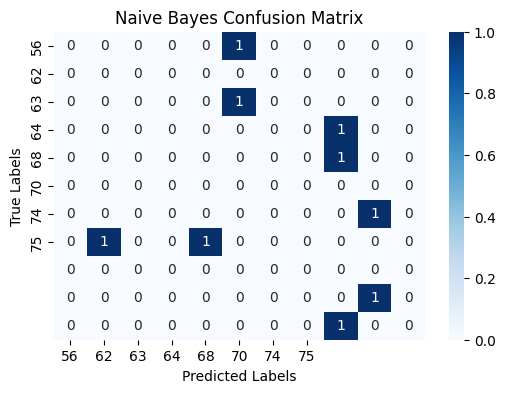

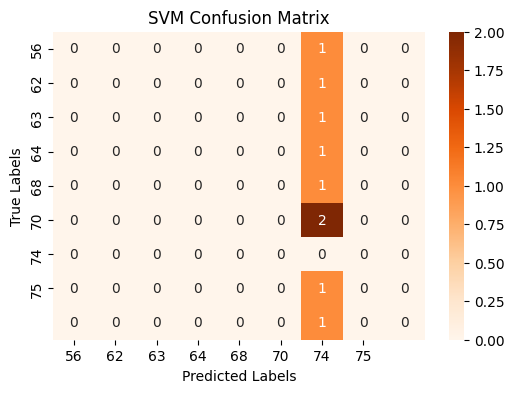

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import precision_recall_fscore_support, ConfusionMatrixDisplay

# Step 1: Load the data
data = {
    'Interest': [8.4, 4.6, 10, 7.4, 9.4, 7.2, 8.4, 1, 10, 8, 8, 7.8, 9.8, 9.6, 9.4, 10, 9.8, 9.8, 9.8, 8, 6.2, 8.019047619, 7.895238095, 8.076190476, 8.152380952, 7.971428571, 8.542857143, 8.685714286, 7.476190476, 8.20952381],
    'Performance': [62, 70, 74, 70, 85, 72, 50, 62, 68, 70, 68, 61, 62, 86, 72, 74, 73, 56, 66, 64, 65, 61, 77, 70, 75, 67, 63, 64, 63, 72]
}

df = pd.DataFrame(data)

# Define features and target
X = df[['Interest']]
y = df['Performance']

# Step 2: Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Step 3: Train Naive Bayes and SVM Models
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

svm_model = SVC(kernel='linear')
svm_model.fit(X_train, y_train)

# Step 4: Evaluate Naive Bayes
nb_predictions_test = nb_model.predict(X_test)
nb_predictions_train = nb_model.predict(X_train)
nb_f1_weighted = precision_recall_fscore_support(y_test, nb_predictions_test, average='weighted')[2]
print(f"Naive Bayes Weighted F1-score: {nb_f1_weighted:.4f}")

# Step 5: Evaluate SVM
svm_predictions_test = svm_model.predict(X_test)
svm_predictions_train = svm_model.predict(X_train)
svm_f1_weighted = precision_recall_fscore_support(y_test, svm_predictions_test, average='weighted')[2]
print(f"SVM Weighted F1-score: {svm_f1_weighted:.4f}")

# Classification report
print("Naive Bayes Classification Report (Test):")
print(classification_report(y_test, nb_predictions_test))

print("SVM Classification Report (Test):")
print(classification_report(y_test, svm_predictions_test))

# Step 6: Confusion Matrix Plot (Naive Bayes)
plt.figure(figsize=(6, 4))
nb_conf_matrix = confusion_matrix(y_test, nb_predictions_test)
sns.heatmap(nb_conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Naive Bayes Confusion Matrix')
plt.show()

# Confusion Matrix Plot (SVM)
plt.figure(figsize=(6, 4))
svm_conf_matrix = confusion_matrix(y_test, svm_predictions_test)
sns.heatmap(svm_conf_matrix, annot=True, fmt='d', cmap='Oranges', xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('SVM Confusion Matrix')
plt.show()